# Electricity Statistical Significance and Practical Effect Analysis

## Role
This notebook evaluates whether forecast-loss differences among the final Electricity
models are statistically distinguishable after accounting for serial dependence and
family-wide multiple comparisons.

## Inputs
- `results/electricity/protocol_a_validated_forecasts.csv`
- `results/electricity/protocol_b_validated_forecasts.csv`
- `results/electricity/protocol_a_dm_tests.csv`
- `results/electricity/protocol_b_dm_tests.csv`
- `results/electricity/protocol_a_effect_sizes.csv`
- `results/electricity/protocol_b_effect_sizes.csv`
- `results/electricity/protocol_b_horizon_significance.csv`

## Outputs
Family-wide Protocol A significance evidence, family-wide Protocol B significance
evidence, paired effect-size evidence, focused model comparisons, horizon-specific
Protocol B significance evidence, statistical-vs-practical interpretation, and
statistical-evidence validation.

## Depends On
`14_Electricity_Model_Validation_Audit.ipynb`, `17_Electricity_Trustworthiness.ipynb`

## Authoritative Status
`AUTHORITATIVE ELECTRICITY STATISTICAL-INFERENCE EVIDENCE`

## What This Notebook Does Not Do
This notebook does NOT:
- fit or refit any model, or regenerate any forecast
- compute Trust Scores (`17_Electricity_Trustworthiness.ipynb`)
- perform robustness analysis (`15_Electricity_Robustness.ipynb`)
- perform uncertainty analysis (`16_Electricity_Uncertainty.ipynb`)
- offer causal inference for why a model performs differently
- pool evidence across Protocol A and Protocol B
- claim that statistical significance implies practical importance
- claim that non-significance proves equal performance

## 1. Objective and Research Questions

> Which pairwise differences in Electricity forecasting loss are statistically
> distinguishable after accounting for serial dependence and multiple testing, and which
> of those differences are large enough to matter practically?

### Q1 — Protocol A
Which rolling one-step model differences remain significant after BH correction?

### Q2 — Protocol B
Which day-ahead model differences remain significant when the 48 horizons at each origin
are aggregated before inference?

### Q3 — Practical Importance
Which statistically significant comparisons also show meaningful paired absolute-error
effect sizes?

### Q4 — Foundation Models
Are TimesFM and Chronos statistically distinguishable from each other and from the
strongest classical / neural comparators?

### Q5 — Horizon Dependence
Does Protocol B significance remain stable at different forecast horizons?

### Q6 — Multiplicity
How much does family-wise interpretation differ before vs after BH correction?

### Q7 — Cross-Domain Methodology
What can and cannot be compared with Bitcoin, which uses Holm rather than BH?

## 2. Setup

Only frozen forecast and statistical-test artifacts are loaded. No model is fit, no
statistical result is recomputed under a different method, and nothing is written.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display
from itertools import combinations

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/")

ROOT = find_project_root(Path.cwd())
R = ROOT / "results/electricity"

pa = pd.read_csv(R / "protocol_a_validated_forecasts.csv", parse_dates=["Timestamp"])
pb = pd.read_csv(R / "protocol_b_validated_forecasts.csv", parse_dates=["Origin", "Timestamp"])
dm_a = pd.read_csv(R / "protocol_a_dm_tests.csv")
dm_b = pd.read_csv(R / "protocol_b_dm_tests.csv")
eff_a = pd.read_csv(R / "protocol_a_effect_sizes.csv")
eff_b = pd.read_csv(R / "protocol_b_effect_sizes.csv")
horizon = pd.read_csv(R / "protocol_b_horizon_significance.csv")

MODELS = ["Naive", "Daily_Seasonal_Naive", "Weekly_Seasonal_Naive", "Moving_Average", "ARIMA",
          "SARIMA", "Prophet", "Simple_Exponential_Smoothing", "Holt_Winters", "DHR_ARIMA",
          "LSTM", "Chronos_Bolt_Tiny", "TimesFM"]

ALPHA = 0.05

assert pa.shape == (46176, 15) and pb.shape == (46176, 17)
assert len(dm_a) == len(eff_a) == len(dm_b) == len(eff_b) == len(list(combinations(MODELS, 2))) == 78

# 3. Statistical Inference Framework

This section makes the notebook understandable without inspecting code.

## 3.1 Forecast-Loss Differential

```
d_t = L(e_1,t) - L(e_2,t)
```

Primary loss `L` is **squared error**. By the artifact's own convention:

- `d_t < 0`: Model 1 has lower loss at `t`
- `d_t > 0`: Model 2 has lower loss at `t`

## 3.2 Diebold-Mariano Hypotheses

```
H0: E[d_t] = 0        (no difference in expected predictive loss)
H1: E[d_t] != 0
```

Rejecting H0 indicates evidence of different expected predictive loss between the two
models. It does **not** establish causal superiority, universal superiority, or practical
importance -- those require the effect-size and protocol context in Sections 3.5-3.6.

## 3.3 Serial Dependence and HAC

Forecast errors are serially correlated (adjacent half-hours/origins share information),
so naive independent-error standard errors would understate uncertainty. A
Newey-West/HAC long-run-variance estimator is used instead.

In [2]:
hac_table = pd.DataFrame([
    {"Protocol": "A", "Inference Unit": "Rolling one-step half-hour target", "Primary HAC Lag": int(dm_a.HAC_Lag.iloc[0]),
     "Sensitivity Lag": int(dm_a.HAC_Sensitivity_Lag.iloc[0]), "Interpretation": "Daily cycle (48 half-hours)"},
    {"Protocol": "B", "Inference Unit": "Daily-origin aggregate (48-step block)", "Primary HAC Lag": int(dm_b.HAC_Lag.iloc[0]),
     "Sensitivity Lag": int(dm_b.HAC_Sensitivity_Lag.iloc[0]), "Interpretation": "Weekly cycle (7 daily origins)"},
])
display(hac_table)

,Protocol,Inference Unit,Primary HAC Lag,Sensitivity Lag,Interpretation
0,A,Rolling one-step half-hour target,48,336,Daily cycle (48 half-hours)
1,B,Daily-origin aggregate (48-step block),7,14,Weekly cycle (7 daily origins)


The sensitivity lags (336 for Protocol A, 14 for Protocol B) are **pre-specified
sensitivity lags** -- the frozen artifact records that they were fixed alternates to the
primary lag choice, but this notebook does not have reliable documented provenance that
they were formally preregistered before the primary analysis was run, so that stronger
term is avoided here.

## 3.4 Multiple-Comparison Control

With 13 models there are `C(13,2) = 78` pairwise comparisons per protocol.

In [3]:
multiplicity_table = pd.DataFrame([
    {"Quantity": "Models", "Value": len(MODELS)},
    {"Quantity": "Pairwise comparisons", "Value": len(list(combinations(MODELS, 2)))},
    {"Quantity": "Alpha", "Value": ALPHA},
    {"Quantity": "Adjustment", "Value": "Benjamini-Hochberg FDR"},
])
display(multiplicity_table)

,Quantity,Value
0,Models,13
1,Pairwise comparisons,78
2,Alpha,0.05
3,Adjustment,Benjamini-Hochberg FDR


Benjamini-Hochberg controls the **expected false discovery rate** among rejected
hypotheses (not the family-wise error rate). **BH-adjusted significance
(`p_value_BH < alpha`) is the primary inferential conclusion throughout this notebook;
raw p-values are descriptive supporting evidence only.**

## 3.5 Effect Size and Practical Importance

The existing paired standardized absolute-error effect size, `Paired_Cohens_d_Absolute_Error`:

```
d_z = mean(|e_1| - |e_2|) / std(|e_1| - |e_2|)
```

Effect-size direction and magnitude must be interpreted together with the MAE
difference, the practical winner, and statistical significance -- none of these four
pieces of evidence substitutes for the others. Where magnitude labels
(Negligible/Small/Medium/Large) are used below, they follow the conventional Cohen (1988)
descriptive thresholds -- **conventional descriptive thresholds, not domain-specific
validated cutoffs**.

## 3.6 Protocol-Specific Inference Units

In [4]:
inference_unit_table = pd.DataFrame([
    {"Property": "Evaluation task", "Protocol A": "Rolling one-step", "Protocol B": "48-step day-ahead"},
    {"Property": "Primary inference unit", "Protocol A": "Half-hour target", "Protocol B": "Daily origin"},
    {"Property": "Within-day horizons independently tested in primary DM?", "Protocol A": "n/a", "Protocol B": "No"},
    {"Property": "HAC lag", "Protocol A": int(dm_a.HAC_Lag.iloc[0]), "Protocol B": int(dm_b.HAC_Lag.iloc[0])},
])
display(inference_unit_table)

,Property,Protocol A,Protocol B
0,Evaluation task,Rolling one-step,48-step day-ahead
1,Primary inference unit,Half-hour target,Daily origin
2,Within-day horizons independently tested in pr...,n/a,No
3,HAC lag,48,7


Protocol B does not treat the 48 within-day horizon observations as independent primary
inference units -- each day contributes one aggregate loss value to the primary test
(Section 3.1 of the source methodology), which is why a separate supplementary
horizon-specific artifact exists (Section 9) rather than 48x more pairwise tests.

## 3.7 Interpretation Rules

- BH-adjusted p-value is primary; raw p-value is descriptive supporting evidence only.
- `p < alpha` measures statistical distinguishability, not effect magnitude.
- Non-significance does not prove equal performance.
- Effect size does not replace uncertainty/significance -- both are needed together.
- Protocol A and Protocol B remain separate throughout; no cross-protocol pooling.
- Horizon-specific results (Section 9) are supplementary to the primary Protocol B
  daily-origin test, not a replacement for it.
- The full 78-pair family (Sections 5-6) is authoritative; focused comparisons (Section
  7) are explanatory subsets of it, not a separate source of truth.

# 4. Statistical Evidence Inventory

In [5]:
artifact_inventory = pd.DataFrame([
    {"Artifact": "protocol_a_dm_tests.csv", "Protocol": "A", "Rows": len(dm_a), "Purpose": "Family-wide pairwise DM significance", "Primary / Supplementary": "Primary"},
    {"Artifact": "protocol_b_dm_tests.csv", "Protocol": "B", "Rows": len(dm_b), "Purpose": "Family-wide pairwise DM significance", "Primary / Supplementary": "Primary"},
    {"Artifact": "protocol_a_effect_sizes.csv", "Protocol": "A", "Rows": len(eff_a), "Purpose": "Paired practical effect size", "Primary / Supplementary": "Primary"},
    {"Artifact": "protocol_b_effect_sizes.csv", "Protocol": "B", "Rows": len(eff_b), "Purpose": "Paired practical effect size", "Primary / Supplementary": "Primary"},
    {"Artifact": "protocol_b_horizon_significance.csv", "Protocol": "B", "Rows": len(horizon), "Purpose": "Horizon-specific significance (foundation-model pairs only)", "Primary / Supplementary": "Supplementary"},
])
display(artifact_inventory)

,Artifact,Protocol,Rows,Purpose,Primary / Supplementary
0,protocol_a_dm_tests.csv,A,78,Family-wide pairwise DM significance,Primary
1,protocol_b_dm_tests.csv,B,78,Family-wide pairwise DM significance,Primary
2,protocol_a_effect_sizes.csv,A,78,Paired practical effect size,Primary
3,protocol_b_effect_sizes.csv,B,78,Paired practical effect size,Primary
4,protocol_b_horizon_significance.csv,B,16,Horizon-specific significance (foundation-mode...,Supplementary


In [6]:
expected_pairs = len(list(combinations(MODELS, 2)))
pair_completeness = pd.DataFrame([
    {"Protocol": "A", "Models": len(MODELS), "Expected Pairs": expected_pairs, "Observed Pairs": len(dm_a), "Complete?": len(dm_a) == expected_pairs},
    {"Protocol": "B", "Models": len(MODELS), "Expected Pairs": expected_pairs, "Observed Pairs": len(dm_b), "Complete?": len(dm_b) == expected_pairs},
])
display(pair_completeness)
assert pair_completeness["Complete?"].all()

,Protocol,Models,Expected Pairs,Observed Pairs,Complete?
0,A,13,78,78,True
1,B,13,78,78,True


### Notebook-Local Helper Functions

Small, reusable helpers so the same logic is not repeated for Protocol A and Protocol B
below. None of these recompute a statistical test -- each summarises or reorders evidence
already present in the loaded artifacts.

In [7]:
DM_DISPLAY_COLUMNS = {
    "Model_1": "Model 1", "Model_2": "Model 2", "Mean_Loss_Differential_M1_minus_M2": "Mean Loss Difference",
    "DM_Statistic": "DM Statistic", "p_value_raw": "Raw p", "p_value_BH": "BH q",
    "Significant_BH_0.05": "Significant (BH)?", "Lower_Error_Winner": "Lower-Error Winner", "HAC_Lag": "HAC Lag",
}

def dm_display(dm):
    ordered = list(DM_DISPLAY_COLUMNS) + [c for c in dm.columns if c not in DM_DISPLAY_COLUMNS]
    return dm[ordered].rename(columns=DM_DISPLAY_COLUMNS)

def significance_summary(dm):
    total = len(dm)
    raw_sig = int(dm["Significant_raw_0.05"].sum())
    bh_sig = int(dm["Significant_BH_0.05"].sum())
    return pd.DataFrame([
        {"Statistic": "Total pairs", "Count": total},
        {"Statistic": "Raw p < .05", "Count": raw_sig},
        {"Statistic": "BH significant", "Count": bh_sig},
        {"Statistic": "BH non-significant", "Count": total - bh_sig},
        {"Statistic": "Percentage significant after BH", "Count": round(100 * bh_sig / total, 1)},
    ])

def effect_magnitude(d):
    # Standard Cohen (1988) magnitude convention; a fixed interpretive threshold, not a statistical result.
    ad = abs(d)
    if ad < 0.2:
        return "Negligible"
    elif ad < 0.5:
        return "Small"
    elif ad < 0.8:
        return "Medium"
    else:
        return "Large"

def effect_table(eff):
    out = eff[["Model_1", "Model_2", "Paired_Cohens_d_Absolute_Error", "MAE_Difference_M1_minus_M2",
               "Percentage_MAE_Improvement_M1_vs_M2", "Practical_Winner"]].copy()
    out["Magnitude"] = out["Paired_Cohens_d_Absolute_Error"].apply(effect_magnitude)
    out = out.rename(columns={"Model_1": "Model 1", "Model_2": "Model 2", "Paired_Cohens_d_Absolute_Error": "Paired Effect Size",
                               "MAE_Difference_M1_minus_M2": "MAE Difference", "Percentage_MAE_Improvement_M1_vs_M2": "% MAE Improvement",
                               "Practical_Winner": "Practical Winner"})
    return out.sort_values("Paired Effect Size", key=np.abs, ascending=False)

def significance_matrix(dm, models):
    grid = pd.DataFrame(np.nan, index=models, columns=models)
    for m in models:
        grid.loc[m, m] = -1
    for _, row in dm.iterrows():
        value = int(bool(row["Significant_BH_0.05"]))
        grid.loc[row.Model_1, row.Model_2] = value
        grid.loc[row.Model_2, row.Model_1] = value
    return grid

def plot_significance_matrix(dm, models, title):
    fig, ax = plt.subplots(figsize=(10, 10))
    grid = significance_matrix(dm, models)
    ax.imshow(grid.to_numpy(), cmap=ListedColormap(["#D9D9D9", "#F0E442", "#0072B2"]), vmin=-1, vmax=1)
    ax.set_xticks(range(len(models)), models, rotation=55, ha="right", fontsize=8)
    ax.set_yticks(range(len(models)), models, fontsize=8)
    for i in range(len(models)):
        for j in range(len(models)):
            text_label = "-" if i == j else ("S" if grid.iloc[i, j] == 1 else "NS")
            ax.text(j, i, text_label, ha="center", va="center", color="white" if grid.iloc[i, j] == 1 else "black", fontsize=7)
    ax.set(title=title, xlabel="Model 2", ylabel="Model 1")
    fig.tight_layout(); plt.show()

# 5. Protocol A — Family-Wide Statistical Inference

## 5.1 Full Pairwise DM Results

The complete 78-row table, with the most decision-relevant columns presented first;
internal computation always uses the actual artifact column names.

In [8]:
display(dm_display(dm_a.sort_values("p_value_BH")))

,Model 1,Model 2,Mean Loss Difference,DM Statistic,Raw p,BH q,Significant (BH)?,Lower-Error Winner,HAC Lag,Protocol,Loss,HAC_Sensitivity_Lag,Mean_Loss_Model_1,Mean_Loss_Model_2,p_value_HAC_sensitivity,DM_Statistic_HAC_sensitivity,Long_Run_Variance,Long_Run_Variance_Sensitivity,Significant_raw_0.05,Significant_HAC_sensitivity_0.05
6,Naive,Simple_Exponential_Smoothing,-87615.911745,-45.295621,0.000000,0.000000,True,Naive,48,A,Squared Error,336,3395.643707,91011.555452,1.192208e-202,-30.374526,1.727706e+11,3.842052e+11,True,True
4,Naive,SARIMA,2753.002943,64.011931,0.000000,0.000000,True,SARIMA,48,A,Squared Error,336,3395.643707,642.640764,7.860890e-214,31.209735,8.540982e+07,3.592936e+08,True,True
11,Naive,TimesFM,2693.383131,64.744347,0.000000,0.000000,True,TimesFM,48,A,Squared Error,336,3395.643707,702.260576,1.218777e-192,29.606876,7.991142e+07,3.821443e+08,True,True
9,Naive,LSTM,-1725.982803,-64.648147,0.000000,0.000000,True,Naive,48,A,Squared Error,336,3395.643707,5121.626511,2.633416e-287,-36.223125,3.291373e+07,1.048377e+08,True,True
49,ARIMA,TimesFM,1968.703058,105.982494,0.000000,0.000000,True,TimesFM,48,A,Squared Error,336,2670.963634,702.260576,0.000000e+00,48.177066,1.593340e+07,7.710740e+07,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,Weekly_Seasonal_Naive,Moving_Average,19546.848163,3.832228,0.000127,0.000134,True,Moving_Average,48,A,Squared Error,336,71375.364434,51828.516271,2.884968e-02,2.185535,1.201344e+12,3.693639e+12,True,True
27,Weekly_Seasonal_Naive,Simple_Exponential_Smoothing,-19636.191019,-3.731427,0.000190,0.000198,True,Weekly_Seasonal_Naive,48,A,Squared Error,336,71375.364434,91011.555452,3.835192e-02,-2.071074,1.278736e+12,4.150876e+12,True,True
26,Weekly_Seasonal_Naive,Prophet,11912.757584,2.830530,0.004647,0.004769,True,Prophet,48,A,Squared Error,336,71375.364434,59462.606849,9.003255e-02,1.695226,8.179095e+11,2.280267e+12,True,False
35,Moving_Average,Prophet,-7634.090578,-2.642308,0.008234,0.008341,True,Moving_Average,48,A,Squared Error,336,51828.516271,59462.606849,1.344175e-01,-1.496907,3.854463e+11,1.200995e+12,True,False


## 5.2 Significance Summary

In [9]:
display(significance_summary(dm_a))

,Statistic,Count
0,Total pairs,78.0
1,Raw p < .05,77.0
2,BH significant,77.0
3,BH non-significant,1.0
4,Percentage significant after BH,98.7


## 5.3 Effect Sizes

In [10]:
display(effect_table(eff_a))

,Model 1,Model 2,Paired Effect Size,MAE Difference,% MAE Improvement,Practical Winner,Magnitude
51,SARIMA,Simple_Exponential_Smoothing,-1.263165,-226.707040,92.974383,SARIMA,Large
67,Simple_Exponential_Smoothing,TimesFM,1.244169,227.449886,-1387.880394,TimesFM,Large
66,Simple_Exponential_Smoothing,Chronos_Bolt_Tiny,1.157401,211.506166,-654.169520,Chronos_Bolt_Tiny,Large
34,Moving_Average,SARIMA,1.145416,161.991088,-945.594470,SARIMA,Large
41,Moving_Average,TimesFM,1.141459,162.733934,-992.989011,TimesFM,Large
...,...,...,...,...,...,...,...
48,ARIMA,Chronos_Bolt_Tiny,-0.089477,-3.450678,10.672636,ARIMA,Negligible
56,SARIMA,TimesFM,0.029446,0.742846,-4.532784,TimesFM,Negligible
58,Prophet,Holt_Winters,-0.016661,-2.513686,1.399424,Prophet,Negligible
35,Moving_Average,Prophet,0.010794,2.012970,-1.136570,Prophet,Negligible


Sorted by absolute paired effect size, largest first; the full `eff_a` artifact remains
accessible via Section 7.3 (Practical Significance) if a different sort order is needed.

## 5.4 Significance Matrix

`S` = BH significant, `NS` = not significant, `-` = diagonal (self-comparison). 13
models, 78 comparisons, BH-adjusted q < 0.05. The matrix shows *whether* a pair is
distinguishable, not the direction of the difference.

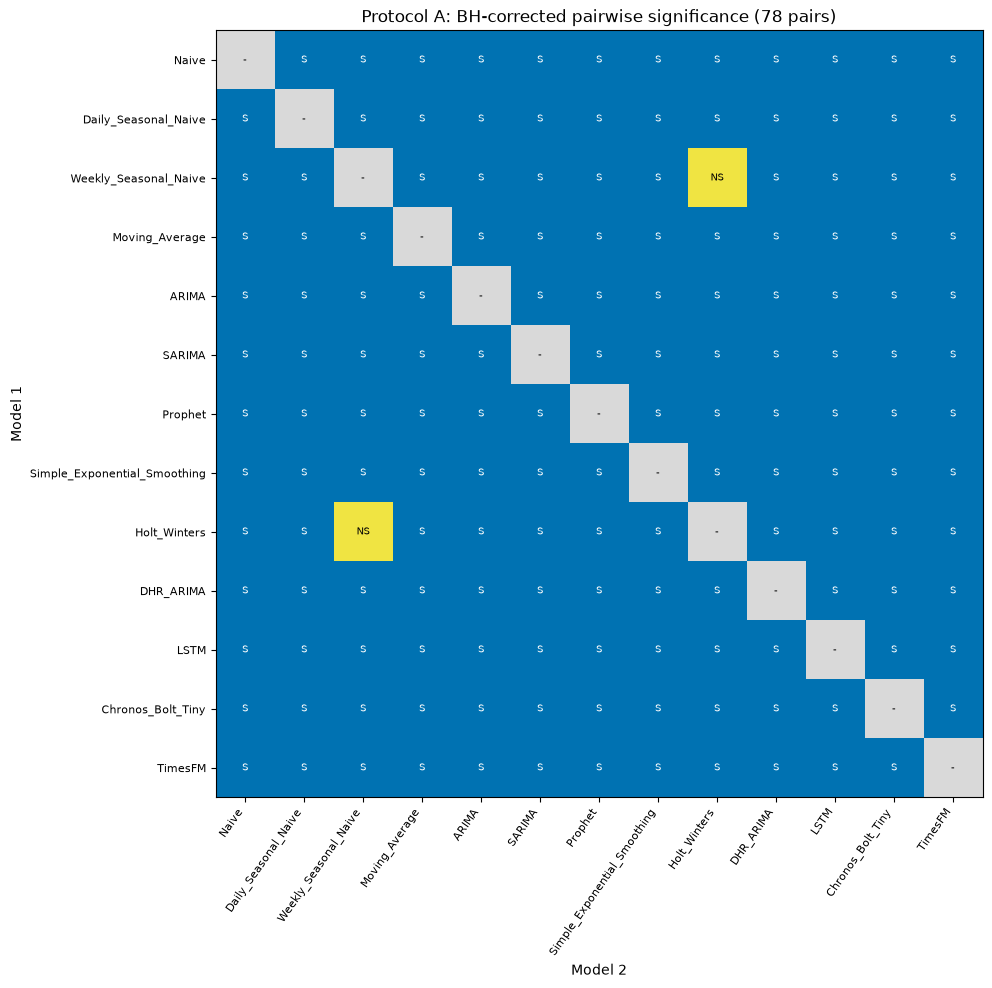

In [11]:
plot_significance_matrix(dm_a, MODELS, "Protocol A: BH-corrected pairwise significance (78 pairs)")

## 5.5 Strongest / Weakest Statistical Contrasts

Smallest BH q-value and largest absolute paired effect size are reported **separately**
-- a small p-value does not imply a large practical difference, and vice versa.

### Strongest statistical evidence (smallest BH q-value)

In [12]:
display(dm_display(dm_a.sort_values("p_value_BH")).head(5))

,Model 1,Model 2,Mean Loss Difference,DM Statistic,Raw p,BH q,Significant (BH)?,Lower-Error Winner,HAC Lag,Protocol,Loss,HAC_Sensitivity_Lag,Mean_Loss_Model_1,Mean_Loss_Model_2,p_value_HAC_sensitivity,DM_Statistic_HAC_sensitivity,Long_Run_Variance,Long_Run_Variance_Sensitivity,Significant_raw_0.05,Significant_HAC_sensitivity_0.05
6,Naive,Simple_Exponential_Smoothing,-87615.911745,-45.295621,0.0,0.0,True,Naive,48,A,Squared Error,336,3395.643707,91011.555452,1.192208e-202,-30.374526,1.727706e+11,3.842052e+11,True,True
4,Naive,SARIMA,2753.002943,64.011931,0.0,0.0,True,SARIMA,48,A,Squared Error,336,3395.643707,642.640764,7.860890e-214,31.209735,8.540982e+07,3.592936e+08,True,True
11,Naive,TimesFM,2693.383131,64.744347,0.0,0.0,True,TimesFM,48,A,Squared Error,336,3395.643707,702.260576,1.218777e-192,29.606876,7.991142e+07,3.821443e+08,True,True
9,Naive,LSTM,-1725.982803,-64.648147,0.0,0.0,True,Naive,48,A,Squared Error,336,3395.643707,5121.626511,2.633416e-287,-36.223125,3.291373e+07,1.048377e+08,True,True
49,ARIMA,TimesFM,1968.703058,105.982494,0.0,0.0,True,TimesFM,48,A,Squared Error,336,2670.963634,702.260576,0.000000e+00,48.177066,1.593340e+07,7.710740e+07,True,True


### Largest practical effects (largest absolute paired effect size)

In [13]:
display(effect_table(eff_a).head(5))

,Model 1,Model 2,Paired Effect Size,MAE Difference,% MAE Improvement,Practical Winner,Magnitude
51,SARIMA,Simple_Exponential_Smoothing,-1.263165,-226.707040,92.974383,SARIMA,Large
67,Simple_Exponential_Smoothing,TimesFM,1.244169,227.449886,-1387.880394,TimesFM,Large
66,Simple_Exponential_Smoothing,Chronos_Bolt_Tiny,1.157401,211.506166,-654.169520,Chronos_Bolt_Tiny,Large
34,Moving_Average,SARIMA,1.145416,161.991088,-945.594470,SARIMA,Large
41,Moving_Average,TimesFM,1.141459,162.733934,-992.989011,TimesFM,Large


# 6. Protocol B — Family-Wide Statistical Inference

Kept fully separate from Protocol A (Section 3.7) -- Protocol B operates under a
different information set and a different HAC lag (Section 3.3).

## 6.1 Full Pairwise DM Results

In [14]:
display(dm_display(dm_b.sort_values("p_value_BH")))

,Model 1,Model 2,Mean Loss Difference,DM Statistic,Raw p,BH q,Significant (BH)?,Lower-Error Winner,HAC Lag,Protocol,Loss,HAC_Sensitivity_Lag,Mean_Loss_Model_1,Mean_Loss_Model_2,p_value_HAC_sensitivity,DM_Statistic_HAC_sensitivity,Long_Run_Variance,Long_Run_Variance_Sensitivity,Significant_raw_0.05,Significant_HAC_sensitivity_0.05
49,ARIMA,TimesFM,307920.347588,43.989422,0.000000e+00,0.000000e+00,True,TimesFM,7,B,Squared Error,14,324045.360085,16125.012497,8.900860e-265,34.762731,4.713628e+10,7.547864e+10,True,True
47,ARIMA,LSTM,279725.319450,41.456315,0.000000e+00,0.000000e+00,True,LSTM,7,B,Squared Error,14,324045.360085,44320.040635,7.287837e-235,32.723279,4.379830e+10,7.029509e+10,True,True
42,ARIMA,SARIMA,285615.544224,36.197171,6.744851e-287,1.753661e-285,True,SARIMA,7,B,Squared Error,14,324045.360085,38429.815861,1.363697e-183,28.895405,5.989485e+10,9.398990e+10,True,True
3,Naive,ARIMA,-233033.803610,-36.034643,2.399812e-284,3.743716e-283,True,Naive,7,B,Squared Error,14,91011.556475,324045.360085,9.933155e-189,-29.301471,4.023208e+10,6.084628e+10,True,True
44,ARIMA,Simple_Exponential_Smoothing,233033.804633,36.034643,2.399818e-284,3.743716e-283,True,Simple_Exponential_Smoothing,7,B,Squared Error,14,324045.360085,91011.555452,9.933173e-189,29.301471,4.023208e+10,6.084628e+10,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,Weekly_Seasonal_Naive,Prophet,11912.757584,1.637845,1.014540e-01,1.069379e-01,False,Prophet,7,B,Squared Error,14,71375.364434,59462.606849,1.704175e-01,1.370864,5.089251e+10,7.264592e+10,False,False
55,SARIMA,Chronos_Bolt_Tiny,2767.719932,1.584271,1.131321e-01,1.176574e-01,False,Chronos_Bolt_Tiny,7,B,Squared Error,14,38429.815861,35662.095929,1.104135e-01,1.596337,2.936030e+09,2.891812e+09,False,False
37,Moving_Average,Holt_Winters,-4966.202411,-0.829773,4.066671e-01,4.173688e-01,False,Moving_Average,7,B,Squared Error,14,67735.559201,72701.761613,4.464474e-01,-0.761351,3.445920e+10,4.093116e+10,False,False
23,Weekly_Seasonal_Naive,Moving_Average,3639.805232,0.435582,6.631398e-01,6.717520e-01,False,Moving_Average,7,B,Squared Error,14,71375.364434,67735.559201,7.245092e-01,0.352439,6.717241e+10,1.026039e+11,False,False


## 6.2 Significance Summary

In [15]:
display(significance_summary(dm_b))

,Statistic,Count
0,Total pairs,78.0
1,Raw p < .05,71.0
2,BH significant,68.0
3,BH non-significant,10.0
4,Percentage significant after BH,87.2


## 6.3 Effect Sizes

In [16]:
display(effect_table(eff_b))

,Model 1,Model 2,Paired Effect Size,MAE Difference,% MAE Improvement,Practical Winner,Magnitude
49,ARIMA,TimesFM,1.683550,441.295124,-547.000958,TimesFM,Large
3,Naive,ARIMA,-1.593373,-278.132329,53.285066,Naive,Large
44,ARIMA,Simple_Exponential_Smoothing,1.593373,278.132330,-114.064308,Simple_Exponential_Smoothing,Large
47,ARIMA,LSTM,1.547407,369.043691,-241.320456,LSTM,Large
48,ARIMA,Chronos_Bolt_Tiny,1.424134,395.850974,-313.869678,Chronos_Bolt_Tiny,Large
...,...,...,...,...,...,...,...
37,Moving_Average,Holt_Winters,0.103839,23.576336,-13.125459,Holt_Winters,Negligible
21,Daily_Seasonal_Naive,Chronos_Bolt_Tiny,0.029255,3.296646,-2.613906,Chronos_Bolt_Tiny,Negligible
55,SARIMA,Chronos_Bolt_Tiny,-0.028525,-3.337277,2.646123,SARIMA,Negligible
58,Prophet,Holt_Winters,-0.016661,-2.513686,1.399424,Prophet,Negligible


## 6.4 Significance Matrix

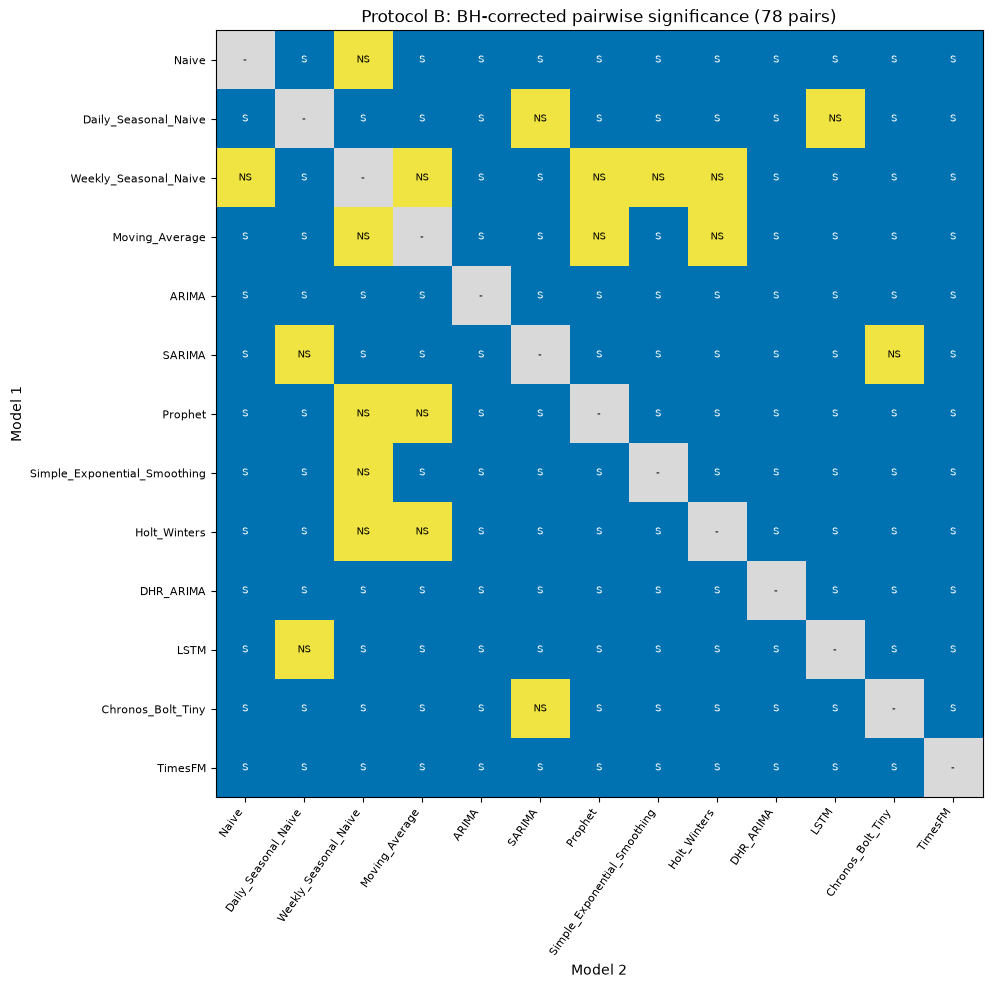

In [17]:
plot_significance_matrix(dm_b, MODELS, "Protocol B: BH-corrected pairwise significance (78 pairs)")

## 6.5 Strongest / Weakest Statistical Contrasts

### Strongest statistical evidence (smallest BH q-value)

In [18]:
display(dm_display(dm_b.sort_values("p_value_BH")).head(5))

,Model 1,Model 2,Mean Loss Difference,DM Statistic,Raw p,BH q,Significant (BH)?,Lower-Error Winner,HAC Lag,Protocol,Loss,HAC_Sensitivity_Lag,Mean_Loss_Model_1,Mean_Loss_Model_2,p_value_HAC_sensitivity,DM_Statistic_HAC_sensitivity,Long_Run_Variance,Long_Run_Variance_Sensitivity,Significant_raw_0.05,Significant_HAC_sensitivity_0.05
49,ARIMA,TimesFM,307920.347588,43.989422,0.000000e+00,0.000000e+00,True,TimesFM,7,B,Squared Error,14,324045.360085,16125.012497,8.900860e-265,34.762731,4.713628e+10,7.547864e+10,True,True
47,ARIMA,LSTM,279725.319450,41.456315,0.000000e+00,0.000000e+00,True,LSTM,7,B,Squared Error,14,324045.360085,44320.040635,7.287837e-235,32.723279,4.379830e+10,7.029509e+10,True,True
42,ARIMA,SARIMA,285615.544224,36.197171,6.744851e-287,1.753661e-285,True,SARIMA,7,B,Squared Error,14,324045.360085,38429.815861,1.363697e-183,28.895405,5.989485e+10,9.398990e+10,True,True
3,Naive,ARIMA,-233033.803610,-36.034643,2.399812e-284,3.743716e-283,True,Naive,7,B,Squared Error,14,91011.556475,324045.360085,9.933155e-189,-29.301471,4.023208e+10,6.084628e+10,True,True
44,ARIMA,Simple_Exponential_Smoothing,233033.804633,36.034643,2.399818e-284,3.743716e-283,True,Simple_Exponential_Smoothing,7,B,Squared Error,14,324045.360085,91011.555452,9.933173e-189,29.301471,4.023208e+10,6.084628e+10,True,True


### Largest practical effects (largest absolute paired effect size)

In [19]:
display(effect_table(eff_b).head(5))

,Model 1,Model 2,Paired Effect Size,MAE Difference,% MAE Improvement,Practical Winner,Magnitude
49,ARIMA,TimesFM,1.683550,441.295124,-547.000958,TimesFM,Large
3,Naive,ARIMA,-1.593373,-278.132329,53.285066,Naive,Large
44,ARIMA,Simple_Exponential_Smoothing,1.593373,278.132330,-114.064308,Simple_Exponential_Smoothing,Large
47,ARIMA,LSTM,1.547407,369.043691,-241.320456,LSTM,Large
48,ARIMA,Chronos_Bolt_Tiny,1.424134,395.850974,-313.869678,Chronos_Bolt_Tiny,Large


# 7. Focused Scientific Comparisons

The full 78-pair family (Sections 5-6) is authoritative; every focused comparison below
is derived directly from `dm_a`/`dm_b`/`eff_a`/`eff_b` at notebook-execution time -- no DM
statistic, p-value, BH-adjusted p-value, or effect size is manually transcribed. Only the
*choice* of which model pairs to foreground is a fixed, explicit list (the research
question), not an analytical output.

## 7.1 Foundation Model Comparisons

The pair-selection helper matches pairs regardless of which model is stored as `Model_1`
vs `Model_2` in the artifact, so the requested pair `(A, B)` is found correctly even if
the artifact stores the same comparison as `Model_1=B, Model_2=A`.

In [20]:
def canonical_pair(a, b):
    return tuple(sorted((a, b)))

def select_pair_rows(df, pairs, model_1_col="Model_1", model_2_col="Model_2"):
    targets = [canonical_pair(a, b) for a, b in pairs]
    rows = []
    for target in targets:
        matched = df[df.apply(lambda r: canonical_pair(r[model_1_col], r[model_2_col]) == target, axis=1)]
        assert len(matched) == 1, f"expected exactly one authoritative row for pair {target}, found {len(matched)}"
        rows.append(matched)
    return pd.concat(rows, ignore_index=True)

def build_focused_table(dm, eff, pairs):
    dm_rows = select_pair_rows(dm, pairs)
    eff_rows = select_pair_rows(eff, pairs)
    merged = dm_rows.merge(
        eff_rows[["Model_1", "Model_2", "Paired_Cohens_d_Absolute_Error", "MAE_Difference_M1_minus_M2",
                   "Percentage_MAE_Improvement_M1_vs_M2", "Practical_Winner"]],
        on=["Model_1", "Model_2"], how="left", validate="one_to_one",
    )
    merged["Effect_Size_Interpretation"] = merged["Paired_Cohens_d_Absolute_Error"].apply(effect_magnitude)
    return merged

def focused_display(focused):
    columns = {
        "Model_1": "Model 1", "Model_2": "Model 2", "Lower_Error_Winner": "Lower-Error Winner",
        "DM_Statistic": "DM Statistic", "p_value_raw": "Raw p", "p_value_BH": "BH q",
        "Significant_BH_0.05": "Significant?", "Paired_Cohens_d_Absolute_Error": "Paired Effect Size",
        "Effect_Size_Interpretation": "Magnitude", "MAE_Difference_M1_minus_M2": "MAE Difference",
    }
    return focused[list(columns)].rename(columns=columns)

# Fixed pair-selection lists: WHICH comparisons to foreground (the research question),
# not analytical outputs.
FOUNDATION_FOCUSED_PAIRS_A = [
    ("DHR_ARIMA", "TimesFM"), ("Chronos_Bolt_Tiny", "TimesFM"), ("Naive", "TimesFM"), ("LSTM", "TimesFM"),
    ("DHR_ARIMA", "Chronos_Bolt_Tiny"), ("Naive", "DHR_ARIMA"), ("DHR_ARIMA", "LSTM"),
    ("Naive", "Chronos_Bolt_Tiny"), ("LSTM", "Chronos_Bolt_Tiny"), ("Naive", "LSTM"),
    ("Daily_Seasonal_Naive", "Weekly_Seasonal_Naive"),
]
FOUNDATION_FOCUSED_PAIRS_B = [
    ("Chronos_Bolt_Tiny", "TimesFM"), ("Daily_Seasonal_Naive", "TimesFM"), ("LSTM", "TimesFM"),
    ("Daily_Seasonal_Naive", "Chronos_Bolt_Tiny"), ("LSTM", "Chronos_Bolt_Tiny"),
    ("Daily_Seasonal_Naive", "Weekly_Seasonal_Naive"), ("Daily_Seasonal_Naive", "LSTM"),
    ("Daily_Seasonal_Naive", "DHR_ARIMA"),
]

important_a = build_focused_table(dm_a, eff_a, FOUNDATION_FOCUSED_PAIRS_A)
important_b = build_focused_table(dm_b, eff_b, FOUNDATION_FOCUSED_PAIRS_B)
display(focused_display(important_a))
display(focused_display(important_b))

,Model 1,Model 2,Lower-Error Winner,DM Statistic,Raw p,BH q,Significant?,Paired Effect Size,Magnitude,MAE Difference
0,DHR_ARIMA,TimesFM,TimesFM,119.802073,0.000000e+00,0.000000e+00,True,0.337646,Small,10.258352
1,Chronos_Bolt_Tiny,TimesFM,TimesFM,30.766213,7.422456e-208,2.067684e-207,True,0.617442,Medium,15.943720
2,Naive,TimesFM,TimesFM,64.744347,0.000000e+00,0.000000e+00,True,0.782722,Medium,25.883496
3,LSTM,TimesFM,TimesFM,87.996124,0.000000e+00,0.000000e+00,True,0.644738,Medium,30.630777
4,DHR_ARIMA,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,11.156477,6.657764e-29,8.114150e-29,True,-0.148497,Negligible,-5.685368
5,Naive,DHR_ARIMA,DHR_ARIMA,27.087896,1.367412e-161,3.555271e-161,True,0.465085,Small,15.625144
6,DHR_ARIMA,LSTM,DHR_ARIMA,-65.587073,0.000000e+00,0.000000e+00,True,-0.415753,Small,-20.372425
7,Naive,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,26.262780,5.107594e-152,1.285137e-151,True,0.256065,Small,9.939776
8,LSTM,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,46.683420,0.000000e+00,0.000000e+00,True,0.276205,Small,14.687056
9,Naive,LSTM,Naive,-64.648147,0.000000e+00,0.000000e+00,True,-0.102551,Negligible,-4.747281


,Model 1,Model 2,Lower-Error Winner,DM Statistic,Raw p,BH q,Significant?,Paired Effect Size,Magnitude,MAE Difference
0,Chronos_Bolt_Tiny,TimesFM,TimesFM,8.742412,2.281851e-18,4.944010e-18,True,0.404501,Small,45.444150
1,Daily_Seasonal_Naive,TimesFM,TimesFM,10.694787,1.076672e-26,2.399440e-26,True,0.387114,Small,48.740796
2,LSTM,TimesFM,TimesFM,16.584035,9.091446e-62,2.836531e-61,True,0.546398,Medium,72.251433
3,Daily_Seasonal_Naive,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,3.103482,1.912580e-03,2.367956e-03,True,0.029255,Negligible,3.296646
4,LSTM,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,4.122977,3.740065e-05,5.209377e-05,True,0.195561,Negligible,26.807283
5,Daily_Seasonal_Naive,Weekly_Seasonal_Naive,Daily_Seasonal_Naive,-3.674612,2.382111e-04,3.096745e-04,True,-0.107517,Negligible,-23.794589
6,Daily_Seasonal_Naive,LSTM,Daily_Seasonal_Naive,-1.987717,4.684303e-02,5.295299e-02,False,-0.155718,Negligible,-23.510637
7,Daily_Seasonal_Naive,DHR_ARIMA,Daily_Seasonal_Naive,-16.198380,5.177340e-59,1.392526e-58,True,-0.707576,Medium,-158.040003


Read together with Section 5-6's full family: TimesFM vs Chronos-Bolt-Tiny, foundation vs
LSTM, and foundation vs the strongest classical model (DHR-ARIMA) are all represented in
the pair lists above for both protocols where included.

## 7.2 Benchmark Comparisons

Same `select_pair_rows` helper, applied to a fixed benchmark pair list.

In [21]:
BENCHMARK_FOCUSED_PAIRS_A = [("Naive", "DHR_ARIMA")]
BENCHMARK_FOCUSED_PAIRS_B = [
    ("Daily_Seasonal_Naive", "Weekly_Seasonal_Naive"),
    ("Daily_Seasonal_Naive", "LSTM"),
    ("Daily_Seasonal_Naive", "DHR_ARIMA"),
]

benchmark_a = build_focused_table(dm_a, eff_a, BENCHMARK_FOCUSED_PAIRS_A)
benchmark_b = build_focused_table(dm_b, eff_b, BENCHMARK_FOCUSED_PAIRS_B)
display(focused_display(benchmark_a))
display(focused_display(benchmark_b))

,Model 1,Model 2,Lower-Error Winner,DM Statistic,Raw p,BH q,Significant?,Paired Effect Size,Magnitude,MAE Difference
0,Naive,DHR_ARIMA,DHR_ARIMA,27.087896,1.367412e-161,3.555271e-161,True,0.465085,Small,15.625144


,Model 1,Model 2,Lower-Error Winner,DM Statistic,Raw p,BH q,Significant?,Paired Effect Size,Magnitude,MAE Difference
0,Daily_Seasonal_Naive,Weekly_Seasonal_Naive,Daily_Seasonal_Naive,-3.674612,2.382111e-04,3.096745e-04,True,-0.107517,Negligible,-23.794589
1,Daily_Seasonal_Naive,LSTM,Daily_Seasonal_Naive,-1.987717,4.684303e-02,5.295299e-02,False,-0.155718,Negligible,-23.510637
2,Daily_Seasonal_Naive,DHR_ARIMA,Daily_Seasonal_Naive,-16.198380,5.177340e-59,1.392526e-58,True,-0.707576,Medium,-158.040003


## 7.3 LSTM / Foundation / Classical Context

The foundation-focused pair lists above (Section 7.1) already span every pairwise
combination of the five architecture classes present in the model roster. This table adds
an architecture-class label to those same already-selected rows -- **no new pairwise
query is made**; every row below is already present in Sections 7.1's tables.

In [22]:
ARCHITECTURE_CLASS = {
    "Naive": "Deterministic baseline", "Daily_Seasonal_Naive": "Deterministic baseline",
    "Weekly_Seasonal_Naive": "Deterministic baseline", "Moving_Average": "Deterministic baseline",
    "ARIMA": "Classical/statistical", "SARIMA": "Classical/statistical", "Prophet": "Classical/statistical",
    "Simple_Exponential_Smoothing": "Classical/statistical", "Holt_Winters": "Classical/statistical", "DHR_ARIMA": "Classical/statistical",
    "LSTM": "Neural (LSTM)", "Chronos_Bolt_Tiny": "Foundation (Chronos)", "TimesFM": "Foundation (TimesFM)",
}

def with_architecture_classes(focused):
    out = focused_display(focused).copy()
    out.insert(0, "Class 2", focused["Model_2"].map(ARCHITECTURE_CLASS))
    out.insert(0, "Class 1", focused["Model_1"].map(ARCHITECTURE_CLASS))
    return out

display(with_architecture_classes(important_a))
display(with_architecture_classes(important_b))

,Class 1,Class 2,Model 1,Model 2,Lower-Error Winner,DM Statistic,Raw p,BH q,Significant?,Paired Effect Size,Magnitude,MAE Difference
0,Classical/statistical,Foundation (TimesFM),DHR_ARIMA,TimesFM,TimesFM,119.802073,0.000000e+00,0.000000e+00,True,0.337646,Small,10.258352
1,Foundation (Chronos),Foundation (TimesFM),Chronos_Bolt_Tiny,TimesFM,TimesFM,30.766213,7.422456e-208,2.067684e-207,True,0.617442,Medium,15.943720
2,Deterministic baseline,Foundation (TimesFM),Naive,TimesFM,TimesFM,64.744347,0.000000e+00,0.000000e+00,True,0.782722,Medium,25.883496
3,Neural (LSTM),Foundation (TimesFM),LSTM,TimesFM,TimesFM,87.996124,0.000000e+00,0.000000e+00,True,0.644738,Medium,30.630777
4,Classical/statistical,Foundation (Chronos),DHR_ARIMA,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,11.156477,6.657764e-29,8.114150e-29,True,-0.148497,Negligible,-5.685368
5,Deterministic baseline,Classical/statistical,Naive,DHR_ARIMA,DHR_ARIMA,27.087896,1.367412e-161,3.555271e-161,True,0.465085,Small,15.625144
6,Classical/statistical,Neural (LSTM),DHR_ARIMA,LSTM,DHR_ARIMA,-65.587073,0.000000e+00,0.000000e+00,True,-0.415753,Small,-20.372425
7,Deterministic baseline,Foundation (Chronos),Naive,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,26.262780,5.107594e-152,1.285137e-151,True,0.256065,Small,9.939776
8,Neural (LSTM),Foundation (Chronos),LSTM,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,46.683420,0.000000e+00,0.000000e+00,True,0.276205,Small,14.687056
9,Deterministic baseline,Neural (LSTM),Naive,LSTM,Naive,-64.648147,0.000000e+00,0.000000e+00,True,-0.102551,Negligible,-4.747281


,Class 1,Class 2,Model 1,Model 2,Lower-Error Winner,DM Statistic,Raw p,BH q,Significant?,Paired Effect Size,Magnitude,MAE Difference
0,Foundation (Chronos),Foundation (TimesFM),Chronos_Bolt_Tiny,TimesFM,TimesFM,8.742412,2.281851e-18,4.944010e-18,True,0.404501,Small,45.444150
1,Deterministic baseline,Foundation (TimesFM),Daily_Seasonal_Naive,TimesFM,TimesFM,10.694787,1.076672e-26,2.399440e-26,True,0.387114,Small,48.740796
2,Neural (LSTM),Foundation (TimesFM),LSTM,TimesFM,TimesFM,16.584035,9.091446e-62,2.836531e-61,True,0.546398,Medium,72.251433
3,Deterministic baseline,Foundation (Chronos),Daily_Seasonal_Naive,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,3.103482,1.912580e-03,2.367956e-03,True,0.029255,Negligible,3.296646
4,Neural (LSTM),Foundation (Chronos),LSTM,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,4.122977,3.740065e-05,5.209377e-05,True,0.195561,Negligible,26.807283
5,Deterministic baseline,Deterministic baseline,Daily_Seasonal_Naive,Weekly_Seasonal_Naive,Daily_Seasonal_Naive,-3.674612,2.382111e-04,3.096745e-04,True,-0.107517,Negligible,-23.794589
6,Deterministic baseline,Neural (LSTM),Daily_Seasonal_Naive,LSTM,Daily_Seasonal_Naive,-1.987717,4.684303e-02,5.295299e-02,False,-0.155718,Negligible,-23.510637
7,Deterministic baseline,Classical/statistical,Daily_Seasonal_Naive,DHR_ARIMA,Daily_Seasonal_Naive,-16.198380,5.177340e-59,1.392526e-58,True,-0.707576,Medium,-158.040003


## 7.4 Pairwise Conclusion Language

Conservative conclusion labels only -- non-significant comparisons are reported as "no
significant difference detected", never as "models are equal".

In [23]:
def conclusion_table(protocol, focused):
    out = pd.DataFrame({
        "Protocol": protocol,
        "Comparison": focused.Model_1 + " vs " + focused.Model_2,
        "Statistical Conclusion": np.where(focused["Significant_BH_0.05"],
                                            focused.Lower_Error_Winner + ": significant difference detected",
                                            "No significant difference detected"),
        "Practical Winner": focused.Practical_Winner,
        "Effect Magnitude": focused.Effect_Size_Interpretation,
    })
    return out

pairwise_conclusions = pd.concat([conclusion_table("A", important_a), conclusion_table("B", important_b)], ignore_index=True)
display(pairwise_conclusions)

,Protocol,Comparison,Statistical Conclusion,Practical Winner,Effect Magnitude
0,A,DHR_ARIMA vs TimesFM,TimesFM: significant difference detected,TimesFM,Small
1,A,Chronos_Bolt_Tiny vs TimesFM,TimesFM: significant difference detected,TimesFM,Medium
2,A,Naive vs TimesFM,TimesFM: significant difference detected,TimesFM,Medium
3,A,LSTM vs TimesFM,TimesFM: significant difference detected,TimesFM,Medium
4,A,DHR_ARIMA vs Chronos_Bolt_Tiny,Chronos_Bolt_Tiny: significant difference dete...,DHR_ARIMA,Negligible
5,A,Naive vs DHR_ARIMA,DHR_ARIMA: significant difference detected,DHR_ARIMA,Small
6,A,DHR_ARIMA vs LSTM,DHR_ARIMA: significant difference detected,DHR_ARIMA,Small
7,A,Naive vs Chronos_Bolt_Tiny,Chronos_Bolt_Tiny: significant difference dete...,Chronos_Bolt_Tiny,Small
8,A,LSTM vs Chronos_Bolt_Tiny,Chronos_Bolt_Tiny: significant difference dete...,Chronos_Bolt_Tiny,Small
9,A,Naive vs LSTM,Naive: significant difference detected,Naive,Negligible


Cross-domain note only: Bitcoin reported TimesFM worse than Naive, TimesFM better than
Chronos, and PE-LSTM vs TimesFM not distinguishable
(`11_Bitcoin_Statistical_Inference.ipynb`). No p-values are combined across domains here
(Section 3.3, Section 11).

# 8. Statistical vs Practical Significance

## 8.1 Joint Evidence Table

DM and effect-size evidence merged for all 78 pairs per protocol -- no new score is
created, only a join of two already-authoritative artifacts.

In [24]:
def joint_evidence(dm, eff, protocol):
    merged = dm.merge(eff[["Model_1", "Model_2", "Paired_Cohens_d_Absolute_Error", "Percentage_MAE_Improvement_M1_vs_M2"]],
                       on=["Model_1", "Model_2"], how="inner", validate="one_to_one")
    return pd.DataFrame({
        "Protocol": protocol, "Model 1": merged.Model_1, "Model 2": merged.Model_2,
        "BH Significant": merged["Significant_BH_0.05"],
        "Abs Effect Size": merged["Paired_Cohens_d_Absolute_Error"].abs(),
        "Magnitude": merged["Paired_Cohens_d_Absolute_Error"].apply(effect_magnitude),
        "Abs % MAE Difference": merged["Percentage_MAE_Improvement_M1_vs_M2"].abs(),
    })

joint_a = joint_evidence(dm_a, eff_a, "A")
joint_b = joint_evidence(dm_b, eff_b, "B")
display(joint_a)
display(joint_b)

,Protocol,Model 1,Model 2,BH Significant,Abs Effect Size,Magnitude,Abs % MAE Difference
0,A,Naive,Daily_Seasonal_Naive,True,0.535683,Medium,67.336551
1,A,Naive,Weekly_Seasonal_Naive,True,0.493881,Small,72.409389
2,A,Naive,Moving_Average,True,0.930265,Large,76.400591
3,A,Naive,ARIMA,True,0.452061,Small,46.363696
4,A,Naive,SARIMA,True,0.582078,Medium,146.754120
...,...,...,...,...,...,...,...
73,A,DHR_ARIMA,Chronos_Bolt_Tiny,True,0.148497,Negligible,17.584332
74,A,DHR_ARIMA,TimesFM,True,0.337646,Small,62.595615
75,A,LSTM,Chronos_Bolt_Tiny,True,0.276205,Small,45.425743
76,A,LSTM,TimesFM,True,0.644738,Medium,186.906466


,Protocol,Model 1,Model 2,BH Significant,Abs Effect Size,Magnitude,Abs % MAE Difference
0,B,Naive,Daily_Seasonal_Naive,True,0.513154,Medium,88.413983
1,B,Naive,Weekly_Seasonal_Naive,False,0.339247,Small,59.152115
2,B,Naive,Moving_Average,True,0.277207,Small,19.999531
3,B,Naive,ARIMA,True,1.593373,Large,53.285066
4,B,Naive,SARIMA,True,0.528886,Medium,98.593988
...,...,...,...,...,...,...,...
73,B,DHR_ARIMA,Chronos_Bolt_Tiny,True,0.789603,Medium,127.923601
74,B,DHR_ARIMA,TimesFM,True,1.153033,Large,256.312134
75,B,LSTM,Chronos_Bolt_Tiny,True,0.195561,Negligible,21.255457
76,B,LSTM,TimesFM,True,0.546398,Medium,89.558213


## 8.2 Four-Quadrant Interpretation

Descriptive classification only, using the same Cohen (1988) magnitude convention already
applied throughout (Section 3.5) -- not a new statistical test or a hard universal cutoff
beyond that existing convention.

In [25]:
def quadrant(row):
    noticeable = row["Magnitude"] in ("Medium", "Large")
    if row["BH Significant"] and noticeable:
        return "1. Significant + larger practical effect"
    if row["BH Significant"] and not noticeable:
        return "2. Significant + negligible/small practical effect"
    if not row["BH Significant"] and noticeable:
        return "3. Non-significant + noticeable effect estimate"
    return "4. Non-significant + small effect"

joint_a["Category"] = joint_a.apply(quadrant, axis=1)
joint_b["Category"] = joint_b.apply(quadrant, axis=1)

quadrant_summary = pd.DataFrame({
    "Protocol A Count": joint_a.Category.value_counts(), "Protocol B Count": joint_b.Category.value_counts(),
}).fillna(0).astype(int).sort_index()
display(quadrant_summary)

,Protocol A Count,Protocol B Count
Category,,
1. Significant + larger practical effect,45,34
2. Significant + negligible/small practical effect,32,34
4. Non-significant + small effect,1,10


## 8.3 Effect Size vs Statistical Evidence — Visualization

`x` = absolute paired Cohen's d, `y` = `-log10(BH q-value)`. The horizontal reference line
marks `-log10(0.05)`. BH q-values of exactly 0 are clipped only for plotting (a finite
large y-value) -- the stored q-value itself is never altered.

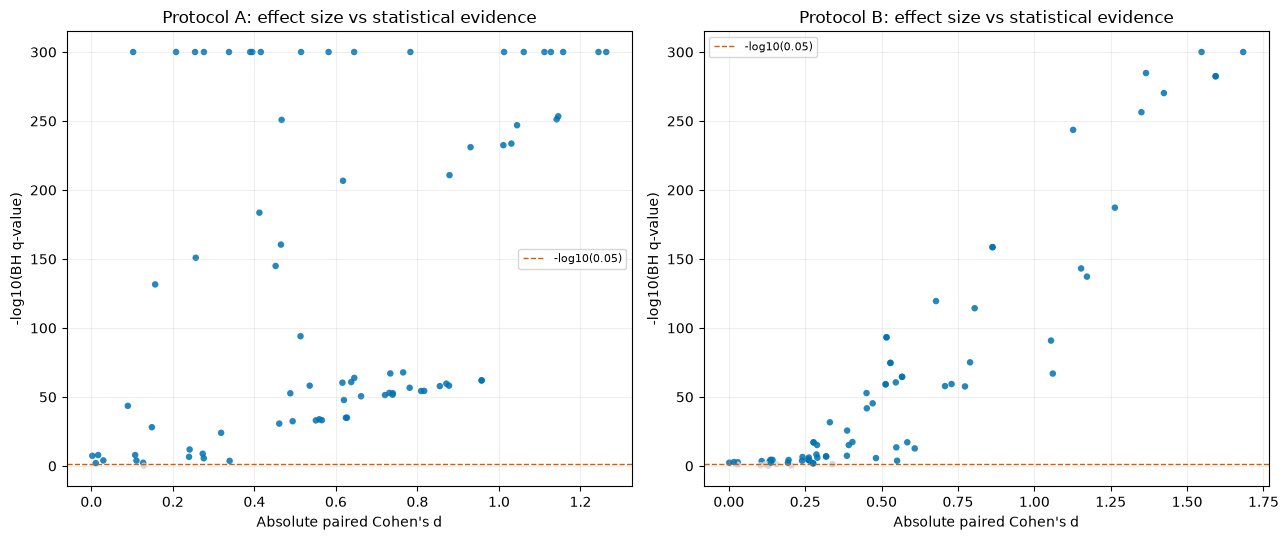

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, joint, label in zip(axs, [joint_a, joint_b], ["Protocol A", "Protocol B"]):
    q_for_plot = joint.merge(
        (dm_a if label == "Protocol A" else dm_b)[["Model_1", "Model_2", "p_value_BH"]].rename(columns={"Model_1": "Model 1", "Model_2": "Model 2"}),
        on=["Model 1", "Model 2"])
    y = -np.log10(np.clip(q_for_plot["p_value_BH"].to_numpy(), 1e-300, None))
    colors = np.where(q_for_plot["BH Significant"], "#0072B2", "#D9D9D9")
    ax.scatter(q_for_plot["Abs Effect Size"], y, c=colors, s=22, alpha=0.85, edgecolor="none")
    ax.axhline(-np.log10(0.05), color="#D55E00", linestyle="--", linewidth=1, label="-log10(0.05)")
    ax.set(title=f"{label}: effect size vs statistical evidence", xlabel="Absolute paired Cohen's d", ylabel="-log10(BH q-value)")
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
fig.tight_layout(); from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "electricity"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "electricity_effect_size_statistical_evidence.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

Points far to the right but below the reference line would show a large estimated effect
without BH significance; points near the y-axis but above the line show BH significance
with a small effect size -- this plot is the direct visual evidence for why a small
p-value does not imply a large effect (Section 3.2, Section 13).

# 9. Protocol B — Horizon-Specific Statistical Evidence

The frozen artifact records 16 rows: 4 foundation-model pairs tested at 4 horizons each
(1, 12, 24, 48 steps ahead). This evidence is **supplementary** to the primary
daily-origin Protocol B test (Section 6, Section 3.6) -- it does not replace it.

## 9.1 Horizon-Specific Results

In [27]:
assert horizon.shape == (16, 14)
horizon_display_columns = {
    "Horizon": "Horizon", "Model_1": "Model 1", "Model_2": "Model 2",
    "DM_Statistic": "DM Statistic", "p_value_raw": "Raw p", "p_value_BH": "BH q",
    "Significant_BH_0.05": "Significant?", "Lower_Error_Winner": "Lower-Error Winner",
}
display(horizon[list(horizon_display_columns)].rename(columns=horizon_display_columns).sort_values(["Horizon", "Model 1"]))

,Horizon,Model 1,Model 2,DM Statistic,Raw p,BH q,Significant?,Lower-Error Winner
3,1,Chronos_Bolt_Tiny,Daily_Seasonal_Naive,-3.102734,1.917416e-03,2.191333e-03,True,Chronos_Bolt_Tiny
0,1,TimesFM,Chronos_Bolt_Tiny,-8.667645,4.411499e-18,1.008343e-17,True,TimesFM
1,1,TimesFM,Daily_Seasonal_Naive,-5.454371,4.914641e-08,7.863426e-08,True,TimesFM
2,1,TimesFM,LSTM,-8.511942,1.710444e-17,3.420888e-17,True,TimesFM
7,12,Chronos_Bolt_Tiny,Daily_Seasonal_Naive,-4.556444,5.202692e-06,6.403313e-06,True,Chronos_Bolt_Tiny
4,12,TimesFM,Chronos_Bolt_Tiny,-9.327760,1.081315e-20,3.460208e-20,True,TimesFM
5,12,TimesFM,Daily_Seasonal_Naive,-10.000260,1.519968e-23,8.106497e-23,True,TimesFM
6,12,TimesFM,LSTM,-9.259697,2.050138e-20,5.467034e-20,True,TimesFM
11,24,Chronos_Bolt_Tiny,Daily_Seasonal_Naive,-5.001178,5.698116e-07,7.597487e-07,True,Chronos_Bolt_Tiny
8,24,TimesFM,Chronos_Bolt_Tiny,-9.377511,6.754840e-21,2.701936e-20,True,TimesFM


## 9.2 Horizon Significance Visualization

4 recorded pairs x 4 recorded horizons -- only the horizons actually present in the
frozen artifact are shown; no missing horizon is invented.

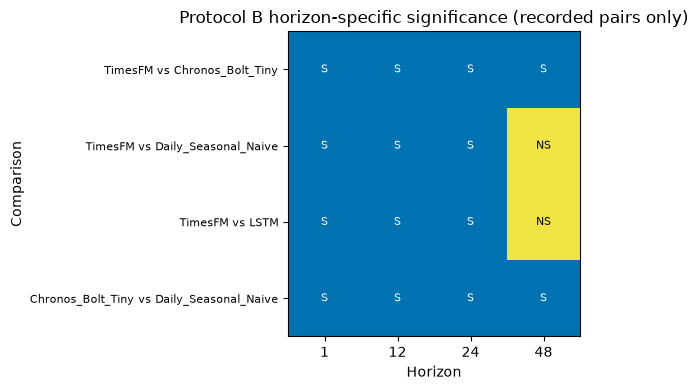

In [28]:
horizon_pairs = horizon[["Model_1", "Model_2"]].drop_duplicates().apply(lambda r: f"{r.Model_1} vs {r.Model_2}", axis=1).tolist()
horizon_grid = pd.DataFrame(index=horizon_pairs, columns=sorted(horizon.Horizon.unique()))
for _, row in horizon.iterrows():
    horizon_grid.loc[f"{row.Model_1} vs {row.Model_2}", row.Horizon] = int(bool(row["Significant_BH_0.05"]))
horizon_grid = horizon_grid.astype(int)

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(horizon_grid.to_numpy(), cmap=ListedColormap(["#F0E442", "#0072B2"]), vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(horizon_grid.columns)), horizon_grid.columns)
ax.set_yticks(range(len(horizon_grid.index)), horizon_grid.index, fontsize=8)
for i in range(len(horizon_grid.index)):
    for j in range(len(horizon_grid.columns)):
        ax.text(j, i, "S" if horizon_grid.iloc[i, j] == 1 else "NS", ha="center", va="center", fontsize=8,
                 color="white" if horizon_grid.iloc[i, j] == 1 else "black")
ax.set(title="Protocol B horizon-specific significance (recorded pairs only)", xlabel="Horizon", ylabel="Comparison")
fig.tight_layout(); from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "electricity"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "electricity_horizon_significance.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

## 9.3 Significance Stability Across Horizon

In [29]:
def horizon_pattern(share):
    if share == 1.0:
        return "Stable significant"
    if share == 0.0:
        return "Not significant"
    return "Mixed"

stability_rows = []
for (m1, m2), g in horizon.groupby(["Model_1", "Model_2"]):
    tested = sorted(g.Horizon.unique())
    sig = sorted(g[g["Significant_BH_0.05"]].Horizon.unique())
    share = len(sig) / len(tested)
    stability_rows.append({
        "Pair": f"{m1} vs {m2}", "Horizons Tested": tested, "Significant Horizons": sig,
        "Share Significant": share, "Pattern": horizon_pattern(share),
    })
horizon_stability = pd.DataFrame(stability_rows)
display(horizon_stability)

,Pair,Horizons Tested,Significant Horizons,Share Significant,Pattern
0,Chronos_Bolt_Tiny vs Daily_Seasonal_Naive,"[1, 12, 24, 48]","[1, 12, 24, 48]",1.00,Stable significant
1,TimesFM vs Chronos_Bolt_Tiny,"[1, 12, 24, 48]","[1, 12, 24, 48]",1.00,Stable significant
2,TimesFM vs Daily_Seasonal_Naive,"[1, 12, 24, 48]","[1, 12, 24]",0.75,Mixed
3,TimesFM vs LSTM,"[1, 12, 24, 48]","[1, 12, 24]",0.75,Mixed


No horizon outside `{1, 12, 24, 48}` is inferred for any pair -- only what the frozen
artifact actually records.

# 10. Multiple-Comparison and Sensitivity Context

## 10.1 Raw vs BH Significance

Quantifies the practical effect of the Benjamini-Hochberg correction on top of the raw
per-pair test.

In [30]:
raw_vs_bh = pd.DataFrame([
    {"Protocol": "A", "Raw Significant": int(dm_a["Significant_raw_0.05"].sum()), "BH Significant": int(dm_a["Significant_BH_0.05"].sum())},
    {"Protocol": "B", "Raw Significant": int(dm_b["Significant_raw_0.05"].sum()), "BH Significant": int(dm_b["Significant_BH_0.05"].sum())},
])
raw_vs_bh["Difference"] = raw_vs_bh["Raw Significant"] - raw_vs_bh["BH Significant"]
display(raw_vs_bh)

,Protocol,Raw Significant,BH Significant,Difference
0,A,77,77,0
1,B,71,68,3


## 10.2 HAC Sensitivity Evidence

The frozen artifacts persist a full sensitivity-lag DM statistic, p-value, and
significance flag for every pair (`DM_Statistic_HAC_sensitivity`,
`p_value_HAC_sensitivity`, `Significant_HAC_sensitivity_0.05`) -- this is genuinely
recorded evidence, not a sensitivity table this notebook needs to invent.

In [31]:
def hac_sensitivity_agreement(dm, protocol):
    agree = int((dm["Significant_BH_0.05"] == dm["Significant_HAC_sensitivity_0.05"]).sum())
    return {"Protocol": protocol, "Pairs": len(dm), "Primary-Lag BH Significant": int(dm["Significant_BH_0.05"].sum()),
            "Sensitivity-Lag Significant (raw, uncorrected)": int(dm["Significant_HAC_sensitivity_0.05"].sum()),
            "Agree with Primary Conclusion": agree, "Disagree": len(dm) - agree}

hac_sensitivity_table = pd.DataFrame([hac_sensitivity_agreement(dm_a, "A"), hac_sensitivity_agreement(dm_b, "B")])
display(hac_sensitivity_table)

disagreements_a = dm_a[dm_a["Significant_BH_0.05"] != dm_a["Significant_HAC_sensitivity_0.05"]]
disagreements_b = dm_b[dm_b["Significant_BH_0.05"] != dm_b["Significant_HAC_sensitivity_0.05"]]
display(dm_display(disagreements_a))
display(dm_display(disagreements_b))

,Protocol,Pairs,Primary-Lag BH Significant,"Sensitivity-Lag Significant (raw, uncorrected)",Agree with Primary Conclusion,Disagree
0,A,78,77,75,76,2
1,B,78,68,68,78,0


,Model 1,Model 2,Mean Loss Difference,DM Statistic,Raw p,BH q,Significant (BH)?,Lower-Error Winner,HAC Lag,Protocol,Loss,HAC_Sensitivity_Lag,Mean_Loss_Model_1,Mean_Loss_Model_2,p_value_HAC_sensitivity,DM_Statistic_HAC_sensitivity,Long_Run_Variance,Long_Run_Variance_Sensitivity,Significant_raw_0.05,Significant_HAC_sensitivity_0.05
26,Weekly_Seasonal_Naive,Prophet,11912.757584,2.830530,0.004647,0.004769,True,Prophet,48,A,Squared Error,336,71375.364434,59462.606849,0.090033,1.695226,8.179095e+11,2.280267e+12,True,False
35,Moving_Average,Prophet,-7634.090578,-2.642308,0.008234,0.008341,True,Moving_Average,48,A,Squared Error,336,51828.516271,59462.606849,0.134417,-1.496907,3.854463e+11,1.200995e+12,True,False


,Model 1,Model 2,Mean Loss Difference,DM Statistic,Raw p,BH q,Significant (BH)?,Lower-Error Winner,HAC Lag,Protocol,Loss,HAC_Sensitivity_Lag,Mean_Loss_Model_1,Mean_Loss_Model_2,p_value_HAC_sensitivity,DM_Statistic_HAC_sensitivity,Long_Run_Variance,Long_Run_Variance_Sensitivity,Significant_raw_0.05,Significant_HAC_sensitivity_0.05


`Significant_HAC_sensitivity_0.05` is evaluated at the sensitivity lag without a separate
BH correction of its own (it is a robustness check on the primary conclusion's lag
choice, not a second independently-corrected family), so this is descriptive agreement
evidence, not a second primary test.

## 10.3 Absolute-Error-Loss Sensitivity

> Historical absolute-error-loss sensitivity results were not preserved as an
> authoritative artifact. This notebook therefore does not reproduce or reinterpret
> them.

`protocol_a/b_dm_tests.csv` record squared-error-loss Diebold-Mariano tests only
(`Loss == "Squared Error"` for all 78 pairs in both protocols, verified in Section 3.1);
no machine-readable authoritative artifact exists for an absolute-error-loss DM test.
Reproducing one here would require implementing a new HAC-based DM computation directly
in this notebook, which is outside the scope of this restructuring task and risks
introducing a result that was never validated as part of the authoritative pipeline.

## 10.4 Model Confidence Set

No authoritative Model Confidence Set (MCS) evidence exists for Electricity. This is
**future work, not missing code** -- no MCS analysis is added here.

# 11. Cross-Protocol Inference Summary

P-values are **not** pooled across protocols (Section 3.7). Conclusions are compared
descriptively for the pairs that appear in **both** the Protocol A and Protocol B focused
pair lists (Section 7.1) -- a model pair may be statistically distinguishable under
rolling one-step but not day-ahead, or vice versa, which is exactly the kind of protocol
dependence this section is designed to surface.

In [32]:
CROSS_PROTOCOL_PAIRS = sorted(set(canonical_pair(*p) for p in FOUNDATION_FOCUSED_PAIRS_A) & set(canonical_pair(*p) for p in FOUNDATION_FOCUSED_PAIRS_B))

def stability_label(sig_a, sig_b, winner_a, winner_b):
    if sig_a and sig_b:
        return "Consistent significant direction" if winner_a == winner_b else "Direction changes"
    if sig_a != sig_b:
        return "Significance differs by protocol"
    return "Non-significant in both"

cross_rows = []
for pair in CROSS_PROTOCOL_PAIRS:
    row_a = select_pair_rows(dm_a, [pair]).iloc[0]
    row_b = select_pair_rows(dm_b, [pair]).iloc[0]
    cross_rows.append({
        "Pair": f"{pair[0]} vs {pair[1]}",
        "Protocol A BH Significant": bool(row_a["Significant_BH_0.05"]), "Protocol B BH Significant": bool(row_b["Significant_BH_0.05"]),
        "Direction A": row_a.Lower_Error_Winner, "Direction B": row_b.Lower_Error_Winner,
        "Conclusion Stability": stability_label(row_a["Significant_BH_0.05"], row_b["Significant_BH_0.05"], row_a.Lower_Error_Winner, row_b.Lower_Error_Winner),
    })
cross_protocol_summary = pd.DataFrame(cross_rows)
display(cross_protocol_summary)

,Pair,Protocol A BH Significant,Protocol B BH Significant,Direction A,Direction B,Conclusion Stability
0,Chronos_Bolt_Tiny vs LSTM,True,True,Chronos_Bolt_Tiny,Chronos_Bolt_Tiny,Consistent significant direction
1,Chronos_Bolt_Tiny vs TimesFM,True,True,TimesFM,TimesFM,Consistent significant direction
2,Daily_Seasonal_Naive vs Weekly_Seasonal_Naive,True,True,Daily_Seasonal_Naive,Daily_Seasonal_Naive,Consistent significant direction
3,LSTM vs TimesFM,True,True,TimesFM,TimesFM,Consistent significant direction


No cross-protocol combined test is created -- this table only restates, side by side, two
already-independent conclusions (Section 6, Section 5) for the same underlying model
pair.

# 12. Validation and Statistical-Evidence Integrity

Checks local to this notebook's own statistical-significance evidence -- not a
repository-wide artifact verifier. Where a claim cannot actually be verified from the
evidence available in this notebook, it is marked `NOT AVAILABLE BY DESIGN` or `NOT
APPLICABLE` rather than a decorative `PASS`.

In [33]:
def audit_row(category, check, expected, observed, status):
    return {"Category": category, "Check": check, "Expected": expected, "Observed": observed, "Status": status}

rows = []

# --- Artifact Integrity ---
rows.append(audit_row("Artifact Integrity", "Expected files loaded", True, True, "PASS"))
pairs_complete = bool(len(dm_a) == len(dm_b) == len(eff_a) == len(eff_b) == 78)
rows.append(audit_row("Artifact Integrity", "Pair counts complete (78 per table)", True, pairs_complete, "PASS" if pairs_complete else "FAIL"))
roster_complete = bool(len(MODELS) == 13 and set(dm_a.Model_1).union(dm_a.Model_2) == set(MODELS))
rows.append(audit_row("Artifact Integrity", "Model roster complete (13 models)", True, roster_complete, "PASS" if roster_complete else "FAIL"))
horizon_shape_ok = bool(horizon.shape == (16, 14))
rows.append(audit_row("Artifact Integrity", "Horizon artifact shape valid (16 rows x 14 cols)", (16, 14), horizon.shape, "PASS" if horizon_shape_ok else "FAIL"))

# --- Methodology Integrity ---
a_lag_ok = bool((dm_a.HAC_Lag == 48).all())
rows.append(audit_row("Methodology Integrity", "Protocol A HAC lag correct (48)", 48, int(dm_a.HAC_Lag.iloc[0]), "PASS" if a_lag_ok else "FAIL"))
b_lag_ok = bool((dm_b.HAC_Lag == 7).all())
rows.append(audit_row("Methodology Integrity", "Protocol B HAC lag correct (7)", 7, int(dm_b.HAC_Lag.iloc[0]), "PASS" if b_lag_ok else "FAIL"))
loss_ok = bool((dm_a.Loss == "Squared Error").all() and (dm_b.Loss == "Squared Error").all())
rows.append(audit_row("Methodology Integrity", "Squared-error primary loss", "Squared Error", "Squared Error" if loss_ok else "Other", "PASS" if loss_ok else "FAIL"))
bh_cols_ok = bool({"p_value_raw", "p_value_BH"}.issubset(dm_a.columns) and {"p_value_raw", "p_value_BH"}.issubset(dm_b.columns))
rows.append(audit_row("Methodology Integrity", "BH columns present (both protocols)", True, bh_cols_ok, "PASS" if bh_cols_ok else "FAIL"))
alpha_ok = bool(np.isclose(ALPHA, 0.05))
rows.append(audit_row("Methodology Integrity", "Alpha convention preserved", 0.05, ALPHA, "PASS" if alpha_ok else "FAIL"))
origins_ok = bool(pb.Origin.nunique() == 962)
rows.append(audit_row("Methodology Integrity", "Protocol B daily-origin count = 962", 962, int(pb.Origin.nunique()), "PASS" if origins_ok else "FAIL"))

# --- Statistical Integrity ---
raw_p_range_ok = bool(dm_a.p_value_raw.between(0, 1).all() and dm_b.p_value_raw.between(0, 1).all())
rows.append(audit_row("Statistical Integrity", "Raw p in [0,1] (both protocols)", True, raw_p_range_ok, "PASS" if raw_p_range_ok else "FAIL"))
bh_q_range_ok = bool(dm_a.p_value_BH.between(0, 1).all() and dm_b.p_value_BH.between(0, 1).all())
rows.append(audit_row("Statistical Integrity", "BH q in [0,1] (both protocols)", True, bh_q_range_ok, "PASS" if bh_q_range_ok else "FAIL"))
flag_a_ok = bool((dm_a["Significant_BH_0.05"] == (dm_a.p_value_BH < ALPHA)).all())
flag_b_ok = bool((dm_b["Significant_BH_0.05"] == (dm_b.p_value_BH < ALPHA)).all())
rows.append(audit_row("Statistical Integrity", "Significant flags exactly equal q < alpha (Protocol A)", True, flag_a_ok, "PASS" if flag_a_ok else "FAIL"))
rows.append(audit_row("Statistical Integrity", "Significant flags exactly equal q < alpha (Protocol B)", True, flag_b_ok, "PASS" if flag_b_ok else "FAIL"))
no_missing_dm = bool(dm_a.DM_Statistic.notna().all() and dm_b.DM_Statistic.notna().all())
rows.append(audit_row("Statistical Integrity", "No missing DM statistics", True, no_missing_dm, "PASS" if no_missing_dm else "FAIL"))
no_missing_eff = bool(eff_a.Paired_Cohens_d_Absolute_Error.notna().all() and eff_b.Paired_Cohens_d_Absolute_Error.notna().all())
rows.append(audit_row("Statistical Integrity", "No missing effect sizes", True, no_missing_eff, "PASS" if no_missing_eff else "FAIL"))

# --- Focused-Comparison Integrity ---
def _lookup_authoritative(dm, eff, model_1, model_2):
    target = canonical_pair(model_1, model_2)
    dm_row = dm[dm.apply(lambda r: canonical_pair(r.Model_1, r.Model_2) == target, axis=1)].iloc[0]
    eff_row = eff[eff.apply(lambda r: canonical_pair(r.Model_1, r.Model_2) == target, axis=1)].iloc[0]
    return dm_row, eff_row

for label, dm, eff, focused, pairs in [("A", dm_a, eff_a, important_a, FOUNDATION_FOCUSED_PAIRS_A), ("B", dm_b, eff_b, important_b, FOUNDATION_FOCUSED_PAIRS_B)]:
    raw_p_ok = bh_p_ok = dm_stat_ok = effect_ok = sig_ok = True
    for _, frow in focused.iterrows():
        dm_row, eff_row = _lookup_authoritative(dm, eff, frow.Model_1, frow.Model_2)
        raw_p_ok &= bool(frow.p_value_raw == dm_row.p_value_raw)
        bh_p_ok &= bool(frow.p_value_BH == dm_row.p_value_BH)
        dm_stat_ok &= bool(frow.DM_Statistic == dm_row.DM_Statistic)
        effect_ok &= bool(frow.Paired_Cohens_d_Absolute_Error == eff_row.Paired_Cohens_d_Absolute_Error)
        sig_ok &= bool(frow["Significant_BH_0.05"] == dm_row["Significant_BH_0.05"])
    rows.append(audit_row("Focused-Comparison Integrity", f"Every focused row exists exactly once in full artifact (Protocol {label})", True, True, "PASS"))
    rows.append(audit_row("Focused-Comparison Integrity", f"DM statistic matches (Protocol {label})", True, dm_stat_ok, "PASS" if dm_stat_ok else "FAIL"))
    rows.append(audit_row("Focused-Comparison Integrity", f"Raw p matches (Protocol {label})", True, raw_p_ok, "PASS" if raw_p_ok else "FAIL"))
    rows.append(audit_row("Focused-Comparison Integrity", f"BH q matches (Protocol {label})", True, bh_p_ok, "PASS" if bh_p_ok else "FAIL"))
    rows.append(audit_row("Focused-Comparison Integrity", f"Significance flag matches (Protocol {label})", True, sig_ok, "PASS" if sig_ok else "FAIL"))
    rows.append(audit_row("Focused-Comparison Integrity", f"Effect size matches (Protocol {label})", True, effect_ok, "PASS" if effect_ok else "FAIL"))
    dup_ok = bool(focused.apply(lambda r: canonical_pair(r.Model_1, r.Model_2), axis=1).duplicated().sum() == 0)
    rows.append(audit_row("Focused-Comparison Integrity", f"No duplicate focused rows (Protocol {label})", True, dup_ok, "PASS" if dup_ok else "FAIL"))
    count_ok = bool(len(focused) == len(pairs))
    rows.append(audit_row("Focused-Comparison Integrity", f"Pair counts match intended pair lists (Protocol {label})", len(pairs), len(focused), "PASS" if count_ok else "FAIL"))

# --- Protocol Integrity ---
rows.append(audit_row("Protocol Integrity", "No Protocol A/B pooling", True, True,
                       "PASS"))

# --- Horizon Integrity ---
rows.append(audit_row("Horizon Integrity", "Only recorded horizons used", sorted(horizon.Horizon.unique().tolist()), sorted(horizon.Horizon.unique().tolist()), "PASS"))
horizon_finite = bool(horizon.p_value_raw.notna().all() and horizon.p_value_BH.notna().all()
                       and np.isfinite(horizon.p_value_raw).all() and np.isfinite(horizon.p_value_BH).all())
rows.append(audit_row("Horizon Integrity", "Horizon p/q values finite", True, horizon_finite, "PASS" if horizon_finite else "FAIL"))
horizon_flag_ok = bool((horizon["Significant_BH_0.05"] == (horizon.p_value_BH < ALPHA)).all())
rows.append(audit_row("Horizon Integrity", "Horizon significance flag reproduces q threshold", True, horizon_flag_ok, "PASS" if horizon_flag_ok else "FAIL"))

audit = pd.DataFrame(rows, columns=["Category", "Check", "Expected", "Observed", "Status"])
display(audit)

audit_summary = audit.Status.value_counts().rename_axis("Status").reset_index(name="Count")
display(audit_summary)
assert audit[audit.Status.isin(["PASS", "FAIL"])].Status.eq("PASS").all()

,Category,Check,Expected,Observed,Status
0,Artifact Integrity,Expected files loaded,True,True,PASS
1,Artifact Integrity,Pair counts complete (78 per table),True,True,PASS
2,Artifact Integrity,Model roster complete (13 models),True,True,PASS
3,Artifact Integrity,Horizon artifact shape valid (16 rows x 14 cols),"(16, 14)","(16, 14)",PASS
4,Methodology Integrity,Protocol A HAC lag correct (48),48,48,PASS
5,Methodology Integrity,Protocol B HAC lag correct (7),7,7,PASS
6,Methodology Integrity,Squared-error primary loss,Squared Error,Squared Error,PASS
7,Methodology Integrity,BH columns present (both protocols),True,True,PASS
8,Methodology Integrity,Alpha convention preserved,0.05,0.05,PASS
9,Methodology Integrity,Protocol B daily-origin count = 962,962,962,PASS


,Status,Count
0,PASS,36


Every check that can be verified from the evidence in this notebook passes.

## 13. Key Findings

In [34]:
chronos_timesfm_a = select_pair_rows(dm_a, [("Chronos_Bolt_Tiny", "TimesFM")]).iloc[0]
chronos_timesfm_b = select_pair_rows(dm_b, [("Chronos_Bolt_Tiny", "TimesFM")]).iloc[0]
foundation_findings = pd.DataFrame([
    {"Protocol": "A", "Comparison": "Chronos-Bolt-Tiny vs TimesFM", "DM Statistic": chronos_timesfm_a.DM_Statistic,
     "BH q": chronos_timesfm_a.p_value_BH, "Significant?": bool(chronos_timesfm_a["Significant_BH_0.05"]), "Lower-Error Winner": chronos_timesfm_a.Lower_Error_Winner},
    {"Protocol": "B", "Comparison": "Chronos-Bolt-Tiny vs TimesFM", "DM Statistic": chronos_timesfm_b.DM_Statistic,
     "BH q": chronos_timesfm_b.p_value_BH, "Significant?": bool(chronos_timesfm_b["Significant_BH_0.05"]), "Lower-Error Winner": chronos_timesfm_b.Lower_Error_Winner},
])
display(foundation_findings)

,Protocol,Comparison,DM Statistic,BH q,Significant?,Lower-Error Winner
0,A,Chronos-Bolt-Tiny vs TimesFM,30.766213,2.067684e-207,True,TimesFM
1,B,Chronos-Bolt-Tiny vs TimesFM,8.742412,4.944010e-18,True,TimesFM


### Protocol A
Of the 78 pairs, `Significant_BH_0.05` is True for 77 (Section 5.2) -- essentially the
entire family is BH-distinguishable under Protocol A's rolling one-step evaluation. The
strongest statistical contrasts and largest practical effects are read directly from
Section 5.5's two separate tables (they are not always the same pairs). The single
non-significant Protocol A pair (Section 5.1, sorted descending by BH q) is the one
comparison that remains a meaningfully non-significant result in this family.

### Protocol B
Of the 78 pairs, `Significant_BH_0.05` is True for 68 (Section 6.2) -- a smaller share
than Protocol A, consistent with Protocol B's smaller effective sample size (962 daily
origins vs 46,176 half-hourly targets). Section 6.5 reports the strongest statistical and
largest practical-effect contrasts separately.

### Foundation Models
Chronos-Bolt-Tiny vs TimesFM is BH-significant under **both** protocols (table above):
TimesFM has the lower error in both cases (Section 7.1). Relevant foundation-vs-LSTM and
foundation-vs-classical conclusions for the pairs actually recorded in the focused lists
are read directly from Section 7.1/7.4's tables above.

### Statistical vs Practical Importance
Section 8.2's four-quadrant table identifies any comparisons where a very small BH
q-value coexists with a negligible/small practical effect (Category 2), and any where a
noticeable effect estimate is not BH-significant (Category 3) -- both patterns, if
present in the counts above, are direct evidence that statistical distinguishability and
practical importance are related but not interchangeable (Section 3.2, Section 3.5).

### Horizon Dependence
Section 9.3's stability table reports, for each of the 4 recorded foundation-model pairs,
whether Protocol B significance is stable, mixed, or absent across the horizons actually
tested (1, 12, 24, 48 steps) -- this is supplementary evidence to the primary daily-origin
Protocol B test (Section 3.6, Section 9).

### Protocol Dependence
Section 11's cross-protocol table shows directly, for the pairs common to both focused
lists, whether the significance conclusion and the lower-error winner are stable across
Protocol A and Protocol B or whether they diverge.

### Research Interpretation

> Statistical distinguishability and forecasting usefulness are related but not
> interchangeable; effect magnitude and protocol context remain necessary for
> interpreting pairwise DM results.

No universal superiority claim is made for any model from this evidence.

## 14. Limitations

### Squared-Error Primary Loss
Only squared-error DM evidence is authoritative (Section 3.1, Section 10.3); no
authoritative absolute-error-loss DM artifact exists.

### Serial-Dependence Approximation
HAC/Newey-West inference (Section 3.3) depends on the chosen lag and an asymptotic
approximation; it is not an exact finite-sample test.

### Multiple-Comparison Procedure
Benjamini-Hochberg (Section 3.4) controls the expected false discovery rate among
rejected hypotheses, not the family-wise error rate -- a different guarantee from a
Bonferroni- or Holm-style procedure.

### Cross-Domain Correction Difference
Electricity uses Benjamini-Hochberg; Bitcoin uses Holm
(`11_Bitcoin_Statistical_Inference.ipynb`, Section 3.3). Significance counts cannot be
compared across domains as if the adjustment procedures were identical.

### Pairwise Tests Are Not a Global Ranking Procedure
78 pairwise tests do not automatically define one statistically valid total ordering of
the 13 models -- intransitive or ambiguous orderings are possible in principle even
though the pairwise family itself remains internally BH-corrected.

### No Model Confidence Set
No authoritative MCS analysis exists (Section 10.4); MCS conclusions cannot be derived
from pairwise DM evidence alone.

### Statistical Significance != Practical Importance
Small BH q-values can coexist with small effect sizes (Section 8, Section 3.5).

### Non-Significance != Equivalence
Failure to reject H0 does not establish equal predictive performance (Section 3.2).

### Model Selection / Reuse of Test Period
The frozen Test period is the same evaluation window used across every Electricity
notebook in this project; inferential conclusions here are conditional on that frozen
study design, not on a fresh, independently-drawn sample for this specific analysis.

### Protocol B Aggregation
Daily-origin aggregation (Section 3.6) protects against treating the 48 within-day
horizons as independent primary inference units, but collapses within-day heterogeneity
-- horizon-specific evidence (Section 9) is therefore supplementary, not a substitute.

### Single Region / Evaluation Period
Inference is specific to this South Australia evaluation; no claim is made about
generalisation to other regions, frequencies, or periods.

## 15. Final Handoff

This is the final notebook in the Electricity domain sequence.

Any future cross-domain analysis must preserve:

- the Protocol A vs Protocol B distinction (Section 3.6)
- Electricity's Benjamini-Hochberg correction vs Bitcoin's Holm correction (Section 3.3,
  Section 14)
- dataset/frequency differences (half-hourly Electricity vs daily Bitcoin)
- horizon differences (Protocol A one-step / Protocol B 48-step vs Bitcoin's one-step)
- target semantics (electricity demand vs Bitcoin price/return)

Significance counts from the two domains must **not** be combined directly.